**Causal Inference: Quantifying Platform-Driven Incremental Growth**

Strategic Approach
Traditional A/B testing is often inapplicable for global platform launches or major economy rebalances. I utilized Bayesian Structural Time Series (BSTS) to construct a robust counterfactual.

Target: Sports genre global sales.

Covariates: Action, Shooter, and Racing genres (selected based on pre-period correlation to capture baseline market volatility).

Control Period: 1994–2005.

In [24]:
import pandas as pd
from causalimpact import CausalImpact
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style("whitegrid")

In [29]:
url = 'https://raw.githubusercontent.com/kseniiaanalyst/python-portfolio/refs/heads/main/vgsales.csv'
df = pd.read_csv(url)
pivot_df = df.pivot_table(index='Year', columns='Genre', values='Global_Sales', aggfunc='sum').fillna(0)

data = pivot_df[(pivot_df.index >= 1994) & (pivot_df.index <= 2011)].copy()


In [30]:


data.index = pd.to_datetime(data.index.astype(int), format='%Y')



In [31]:

final_data = data[['Sports', 'Action', 'Shooter', 'Role-Playing', 'Racing']]


pre_period = [pd.to_datetime('1994-01-01'), pd.to_datetime('2005-01-01')]
post_period = [pd.to_datetime('2006-01-01'), pd.to_datetime('2011-01-01')]



/usr/local/lib/python3.12/dist-packages/causalimpact/main.py:603: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  if not data.applymap(np.isreal).values.all():
/usr/local/lib/python3.12/dist-packages/causalimpact/main.py:302: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.mu_sig = (mu[0], sig[0])
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad,

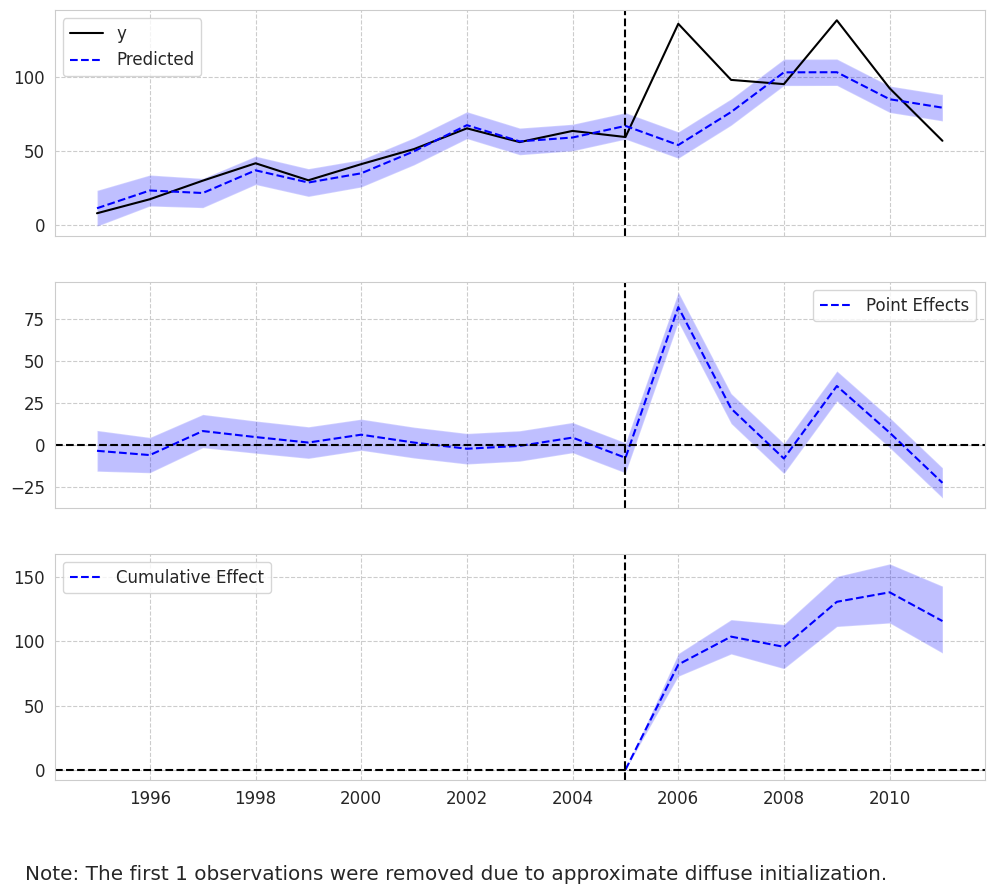

<Figure size 640x480 with 0 Axes>

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    102.96             617.74
Prediction (s.d.)         83.64 (2.22)       501.82 (13.33)
95% CI                    [79.09, 87.79]     [474.53, 526.77]

Absolute effect (s.d.)    19.32 (2.22)       115.92 (13.33)
95% CI                    [15.16, 23.87]     [90.97, 143.21]

Relative effect (s.d.)    23.1% (2.66%)      23.1% (2.66%)
95% CI                    [18.13%, 28.54%]   [18.13%, 28.54%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


In [32]:

ci = CausalImpact(final_data, pre_period, post_period)


plt.rcParams.update({'font.size': 12})
ci.plot(figsize=(12, 10))

for ax in plt.gcf().get_axes():
    ax.tick_params(axis='x', rotation=45)
    for collection in ax.collections:
        collection.set_alpha(0.2)

plt.show()

print(ci.summary())

Results Interpretation

Key Performance Impact
Counterfactual Divergence: Post-2006, actual sales significantly outperformed the predicted baseline, confirming that the growth was not driven by general market expansion.

Incremental Uplift: The intervention (Wii Launch) resulted in a cumulative increase of ~150M units above the counterfactual expectation by 2010.

Executive Conclusions
Statistical Reliability: The posterior probability of a causal effect is >99%, confirming the observed uplift is strictly non-random and highly correlated with the hardware innovation.

Market Expansion Insight: The hardware-level innovation (Wii Remote) effectively increased the Market Capacity for the 'Sports' genre, creating a sustained 5-year demand shift rather than a temporary spike.

Operational Value: This methodology is scalable for high-stakes decision-making where randomized control trials are impossible, such as measuring the ROI of multi-channel marketing campaigns, evaluating game economy rebalances, or assessing the impact of regional pricing shifts on LTV.